# GIIP: Exploratory Data Analysis


This notebook performs data quality checks, temporal trend analysis, and correlation mapping for global vaccine demand. As an analyst, validating these distributions is critical before feeding them into our predictive models.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configure professional styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

## 1. Data Loading & Quality Checks


In [2]:
df = pd.read_csv('../data/vaccine_data.csv')
display(df.head())
print(f'\nDataset shape: {df.shape}')

,Country,Year,"Total Population, as of 1 January (thousands)","Total Population, as of 1 July (thousands)",Births (thousands),"Crude Birth Rate (births per 1,000 population)","Infant Deaths, under age 1 (thousands)","Infant Mortality Rate (infant deaths per 1,000 live births)","Under-Five Deaths, under age 5 (thousands)","Under-Five Mortality (deaths under age 5 per 1,000 live births)",Net Number of Migrants (thousands),"Net Migration Rate (per 1,000 population)",Pop_Age_0(In Thousands),MCV1_TARGET
0,Uzbekistan,2024,36010.454,36361.859,929.292,25.557,11.362,12.202,13.671,14.765,-7.066,-0.194,926.7260,1223.27832
1,Uzbekistan,2023,35294.160,35652.307,943.547,26.465,10.484,11.137,12.621,13.594,-6.004,-0.168,925.9425,1222.24410
2,Uzbekistan,2022,34583.751,34938.955,926.734,26.524,10.311,11.160,12.251,13.546,-5.007,-0.143,906.9520,1197.17664
3,Uzbekistan,2021,33903.640,34243.696,905.756,26.450,10.582,11.757,12.601,14.322,-9.205,-0.269,873.8930,1153.53876
4,Uzbekistan,2020,33269.104,33586.372,860.945,25.634,10.541,12.327,12.566,14.988,-9.208,-0.274,828.5060,1093.62792



Dataset shape: (111, 14)


In [3]:
# Check for missing values to ensure data integrity
missing = df.isnull().sum()
display(missing[missing > 0])

Series([], dtype: int64)

## 2. Target Variable Analysis (Vaccine Demand)


Understanding the distribution of our target variable (`MCV1_TARGET`) helps us identify outliers and determine if normal-distribution assumptions hold true.


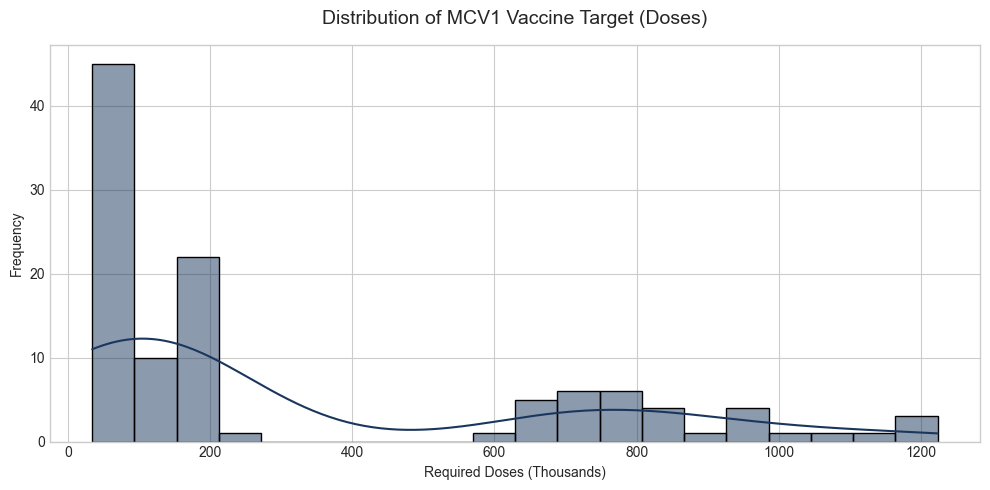

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df['MCV1_TARGET'], bins=20, kde=True, color='#1a365d')
plt.title('Distribution of MCV1 Vaccine Target (Doses)', fontsize=14, pad=15)
plt.xlabel('Required Doses (Thousands)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 3. Time Series Trends by Country


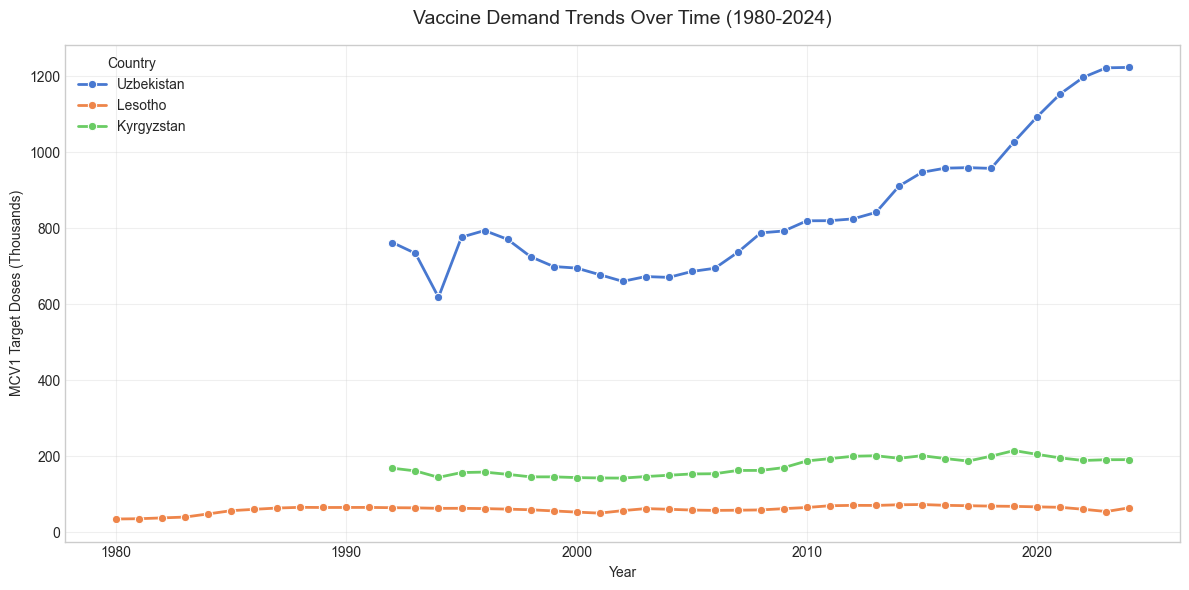

In [5]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='MCV1_TARGET', hue='Country', marker='o', linewidth=2)
plt.title('Vaccine Demand Trends Over Time (1980-2024)', fontsize=14, pad=15)
plt.ylabel('MCV1 Target Doses (Thousands)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Demographic Correlation Analysis


We need to understand which demographic factors drive vaccine demand. High correlation with Births is expected, but measuring the exact linear relationship is key for our regression baseline.


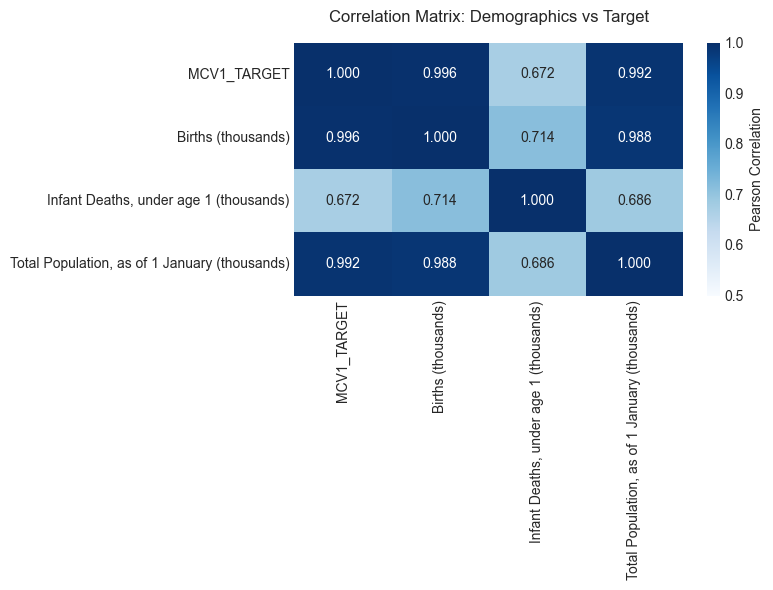

In [6]:
cols = ['MCV1_TARGET', 'Births (thousands)', 'Infant Deaths, under age 1 (thousands)', 'Total Population, as of 1 January (thousands)']
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', vmin=0.5, vmax=1, fmt='.3f', 
            cbar_kws={'label': 'Pearson Correlation'})
plt.title('Correlation Matrix: Demographics vs Target', pad=15)
plt.tight_layout()
plt.show()